# 2.0 FD Solver Validation: FK Reference & Analytical Green's Function

## Overview

This notebook validates the Numba-based displacement FD solver by comparing
its output against independent reference solutions.

We employ two complementary validation strategies:

| Strategy | Method | Independent of project code? |
|----------|--------|------------------------------|
| 1 | FK (semi-analytical) as ground truth, Numba FD with line source | No (uses `fk/`) |
| 2 | 2D analytical Green's function (Hankel) vs Numba FD | **Yes** (scipy only) |

### What this notebook checks

1. **Strategy 1 (FK reference):** The semi-analytical FK method provides
   a reference seismogram for a 1D layered medium. We compare the Numba
   FD solver against FK using an explosive line source (monopole).
   This validates the complete FD pipeline including source injection, PML
   boundary conditions, and time integration.

2. **Strategy 2 (Analytical Green's function):** We compare the Numba FD solver
   against the closed-form 2D elastodynamic Green's function $G_{xx}$ for a
   point body force in a homogeneous full-space. This is the strongest
   independent validation since it uses only `scipy.special.hankel2` — no
   project code involved.

### Pass criteria

- Strategy 1: CC > 0.90 (after time alignment) for FK vs Numba FD
- Strategy 2: CC > 0.95 for Numba FD vs analytical $G_{xx}$


In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from hybrid.config import HybridConfig
from hybrid.fd_displacement import FDDisplacementSolver, build_material_arrays
from hybrid.sources import (
    PointBodyForceSource, LineBodyForceSource, ExplosiveLineSource,
    run_standalone,
)

# Shared Ricker wavelet function
def make_ricker(f0, dt, nt, t0=None):
    if t0 is None:
        t0 = 1.0 / f0
    t = np.arange(nt) * dt
    arg = (np.pi * f0 * (t - t0)) ** 2
    return (1.0 - 2.0 * arg) * np.exp(-arg)


In [2]:
# --- Shared model parameters ---
vp = 6000.0   # m/s
vs = 3464.0   # m/s
rho_val = 2700.0  # kg/m^3

f0 = 2.0      # Hz (dominant frequency)
dx = dz = 200.0  # m
nx = 101
nz = 61
npml = 20
norder = 3

from hybrid.fd_displacement import check_stability
config_tmp = HybridConfig(nx=nx, nz=nz, dx=dx, dz=dz, norder=norder, npml=npml)
dt_stable = check_stability(config_tmp, vp)
dt = 0.9 * dt_stable  # 90% of CFL limit
nt = int(4.0 / dt)    # 4 seconds of simulation

config = HybridConfig(nx=nx, nz=nz, dx=dx, dz=dz, dt=dt, nt=nt, norder=norder, npml=npml)
print(f"Grid: {nx}x{nz}, dx=dz={dx}m, dt={dt:.5f}s, nt={nt}")
print(f"dt_stable={dt_stable:.5f}s, CFL ratio={dt/dt_stable:.2f}")
print(f"Model: vp={vp}, vs={vs}, rho={rho_val}")
print(f"Source: Ricker f0={f0}Hz")

# Build material arrays
vp_2d = np.full((config.nz, config.nx), vp)
vs_2d = np.full((config.nz, config.nx), vs)
rho_2d = np.full((config.nz, config.nx), rho_val)
rho_ext, lam_ext, mu_ext = build_material_arrays(config, vp_2d, vs_2d, rho_2d)

# Time axis
t_arr = np.arange(nt) * dt


Grid: 101x61, dx=dz=200.0m, dt=0.01726s, nt=231
dt_stable=0.01917s, CFL ratio=0.90
Model: vp=6000.0, vs=3464.0, rho=2700.0
Source: Ricker f0=2.0Hz


In [3]:
# --- Utility functions for waveform comparison ---

def waveform_cc(a, b):
    """Pearson correlation coefficient between two traces."""
    a_dm = a - a.mean()
    b_dm = b - b.mean()
    denom = np.linalg.norm(a_dm) * np.linalg.norm(b_dm)
    if denom < 1e-30:
        return 0.0
    return float(np.dot(a_dm, b_dm) / denom)


def find_best_scale(ref, test):
    """L2-optimal scalar amplitude scale: minimizes ||ref - s * test||_2^2."""
    denom = np.dot(test, test)
    if denom < 1e-30:
        return 1.0
    return float(np.dot(ref, test) / denom)


def normalize_trace(tr):
    """Divide trace by its own peak absolute value."""
    return tr / (np.max(np.abs(tr)) + 1e-30)


def overlay_trace(tr):
    """Peak-normalize a trace for waveform / moveout overlay plots."""
    return normalize_trace(tr)


def scale_to_match(ref, test, method="l2"):
    """Return amplitude scale factor (*method* = ``'l2'`` or ``'peak'``)."""
    if method == "l2":
        return find_best_scale(ref, test)
    if method == "peak":
        return (np.max(np.abs(ref)) + 1e-30) / (np.max(np.abs(test)) + 1e-30)
    raise ValueError(f"unknown method: {method!r} (use 'l2' or 'peak')")


def aligned_cc(ref, test):
    """CC after optimal time-shift alignment via cross-correlation."""
    cc_full = np.correlate(ref - ref.mean(), test - test.mean(), mode='full')
    lag = cc_full.argmax() - (len(test) - 1)
    if lag > 0:
        a, b = ref[lag:], test[:len(ref) - lag]
    elif lag < 0:
        a, b = ref[:len(ref) + lag], test[-lag:]
    else:
        a, b = ref, test
    return waveform_cc(a, b), lag


---
## Strategy 1: FK Reference + Line-Source Numba FD

The Numba FD solver uses **2nd-order displacement** with an isotropic explosive
line source (`ExplosiveLineSource`). FK provides the semi-analytical reference
for a 1D homogeneous model.

**Plot scaling:** waveform and moveout figures use `overlay_trace()` (each trace
divided by its own `max|uz|`) so arrival timing and wavelet shape are comparable.
Printed CC / L2 scale factors still use `find_best_scale()` (see utils cell).


In [4]:
# --- Strategy 1: FK reference ---
from fk.engine import compute_fk_seismograms
from fk.model import FKLayerModel
from fk.source import RickerSource
from fk.geometry import rayp_deg_to_si

# Homogeneous half-space FK model (single entry at free surface)
fk_model = FKLayerModel.from_layers(
    vp=[vp], vs=[vs], rho=[rho_val],
    z_top=[0.0],
)

# Source depth for FK & FD comparison (also used by cells 10-11)
iz_line = config.nz - 5
z_src_line = iz_line * dz

rayp_deg = 0.0
p_si = rayp_deg_to_si(rayp_deg)
source_fk = RickerSource(f0=f0, t0=1.0/f0, incidence='P')

# Surface receivers spanning the domain
rcv_x = config.x0 + np.arange(config.nx) * config.dx
rcv_z = np.zeros(config.nx)

fk_result = compute_fk_seismograms(
    fk_model, source_fk, rcv_x,
    dt=dt, nt=nt,
    p_si=p_si,
    receivers_z=rcv_z,
    model_max_depth=z_src_line,
)
print(f"FK result: ux shape={fk_result.ux.shape}, max|uz|={np.max(np.abs(fk_result.uz)):.3e}")

FK result: ux shape=(101, 231), max|uz|=1.999e+00


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [5]:
# --- Strategy 1: Numba FD with explosive line source (monopole) ---

# iz_line and z_src_line defined in cell 9 to match FK z_init
line_wavelet = make_ricker(f0, dt, nt)
line_source = ExplosiveLineSource(iz=iz_line, wavelet=line_wavelet)

# Surface receivers (all x, iz=0)
rcv_ix_all = np.arange(config.npml, config.npml + config.nx)
rcv_iz_all = np.zeros(config.nx, dtype=int)

solver_s1 = FDDisplacementSolver(config, rho_ext, lam_ext, mu_ext)
t0_clock = time.perf_counter()
result_numba_s1 = run_standalone(solver_s1, line_source, nt,
                                 receivers_ix=rcv_ix_all, receivers_iz=rcv_iz_all)
print(f"Numba FD (explosive line source) completed in {time.perf_counter()-t0_clock:.2f}s")
print(f"max|uz| = {np.max(np.abs(result_numba_s1['uz'])):.3e}")

Numba FD (explosive line source) completed in 0.21s
max|uz| = 2.183e-09


In [6]:
# --- Strategy 1: Metrics ---

ircv_center = config.nx // 2
fk_uz = fk_result.uz[ircv_center]
numba_uz = result_numba_s1['uz'][ircv_center]

scale_fk_numba = find_best_scale(fk_uz, numba_uz)
cc_raw = waveform_cc(fk_uz, numba_uz * scale_fk_numba)
cc_aligned, lag = aligned_cc(fk_uz, numba_uz)

print("Strategy 1: FK vs Numba FD")
print("=" * 40)
print(f"FK vs Numba FD (center receiver):")
print(f"  CC (raw)    = {cc_raw:.4f}, scale = {scale_fk_numba:.3e}")
print(f"  CC (aligned)= {cc_aligned:.4f}, lag = {lag} samples ({lag*dt:.4f}s)")
print(f"  {'PASS' if cc_aligned > 0.90 else 'FAIL'} (threshold CC > 0.90)")


Strategy 1: FK vs Numba FD
FK vs Numba FD (center receiver):
  CC (raw)    = 0.9317, scale = 9.021e+08
  CC (aligned)= 0.9873, lag = 1 samples (0.0173s)
  PASS (threshold CC > 0.90)


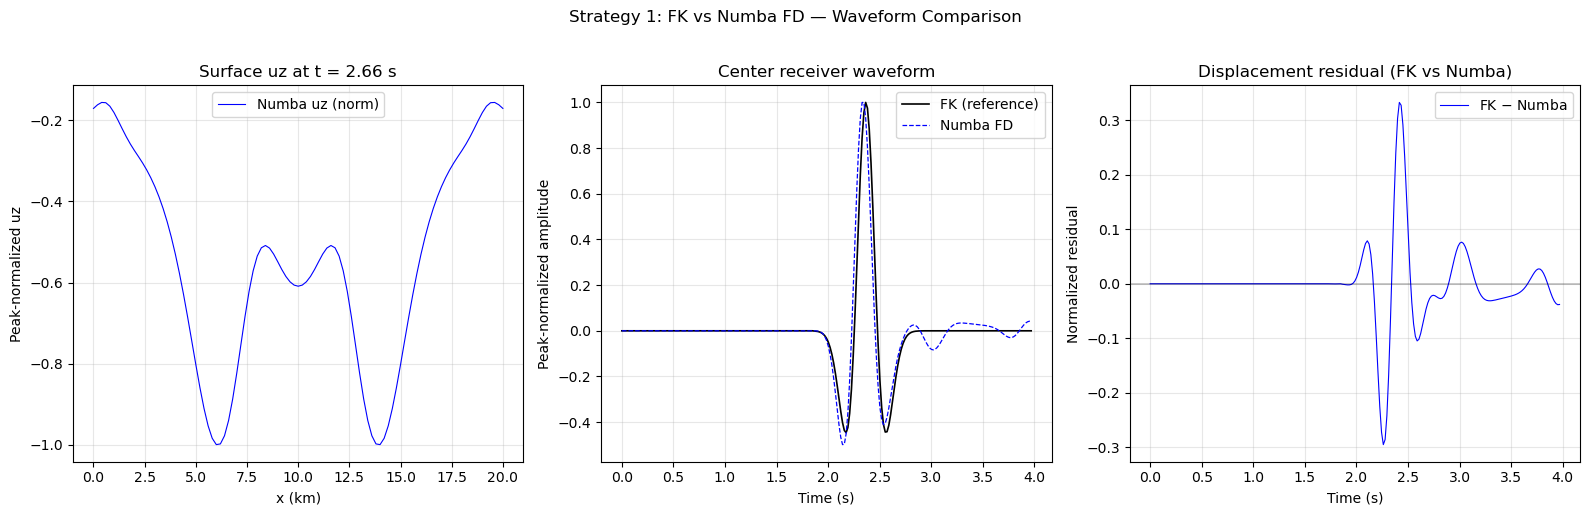

In [7]:
# --- Strategy 1: Waveform Comparison & Residuals ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Surface uz snapshot at a representative time
ax = axes[0]
it_snap_s1 = nt * 2 // 3
numba_surf_s1 = result_numba_s1['uz'][:, it_snap_s1]
ax.plot(rcv_x / 1000, overlay_trace(numba_surf_s1), 'b-', lw=0.8, label='Numba uz (norm)')
ax.set_xlabel('x (km)')
ax.set_ylabel('Peak-normalized uz')
ax.set_title(f'Surface uz at t = {it_snap_s1*dt:.2f} s')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# (b) Center-receiver waveform overlay
ax = axes[1]
ax.plot(t_arr, overlay_trace(fk_uz), 'k-', lw=1.2, label='FK (reference)')
numba_center_s1 = result_numba_s1['uz'][ircv_center]
ax.plot(t_arr, overlay_trace(numba_center_s1), 'b--', lw=0.9, label='Numba FD')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Peak-normalized amplitude')
ax.set_title('Center receiver waveform')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# (c) FK vs Numba residual
ax = axes[2]
scale_numba_s1 = find_best_scale(fk_uz, numba_center_s1)
norm_fk_center = np.max(np.abs(fk_uz)) + 1e-30
diff_numba_s1 = (fk_uz - numba_center_s1 * scale_numba_s1) / norm_fk_center
ax.plot(t_arr, diff_numba_s1, 'b-', lw=0.8, label='FK $-$ Numba')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Normalized residual')
ax.set_title('Displacement residual (FK vs Numba)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.suptitle('Strategy 1: FK vs Numba FD — Waveform Comparison', y=1.02)
plt.tight_layout()
plt.show()


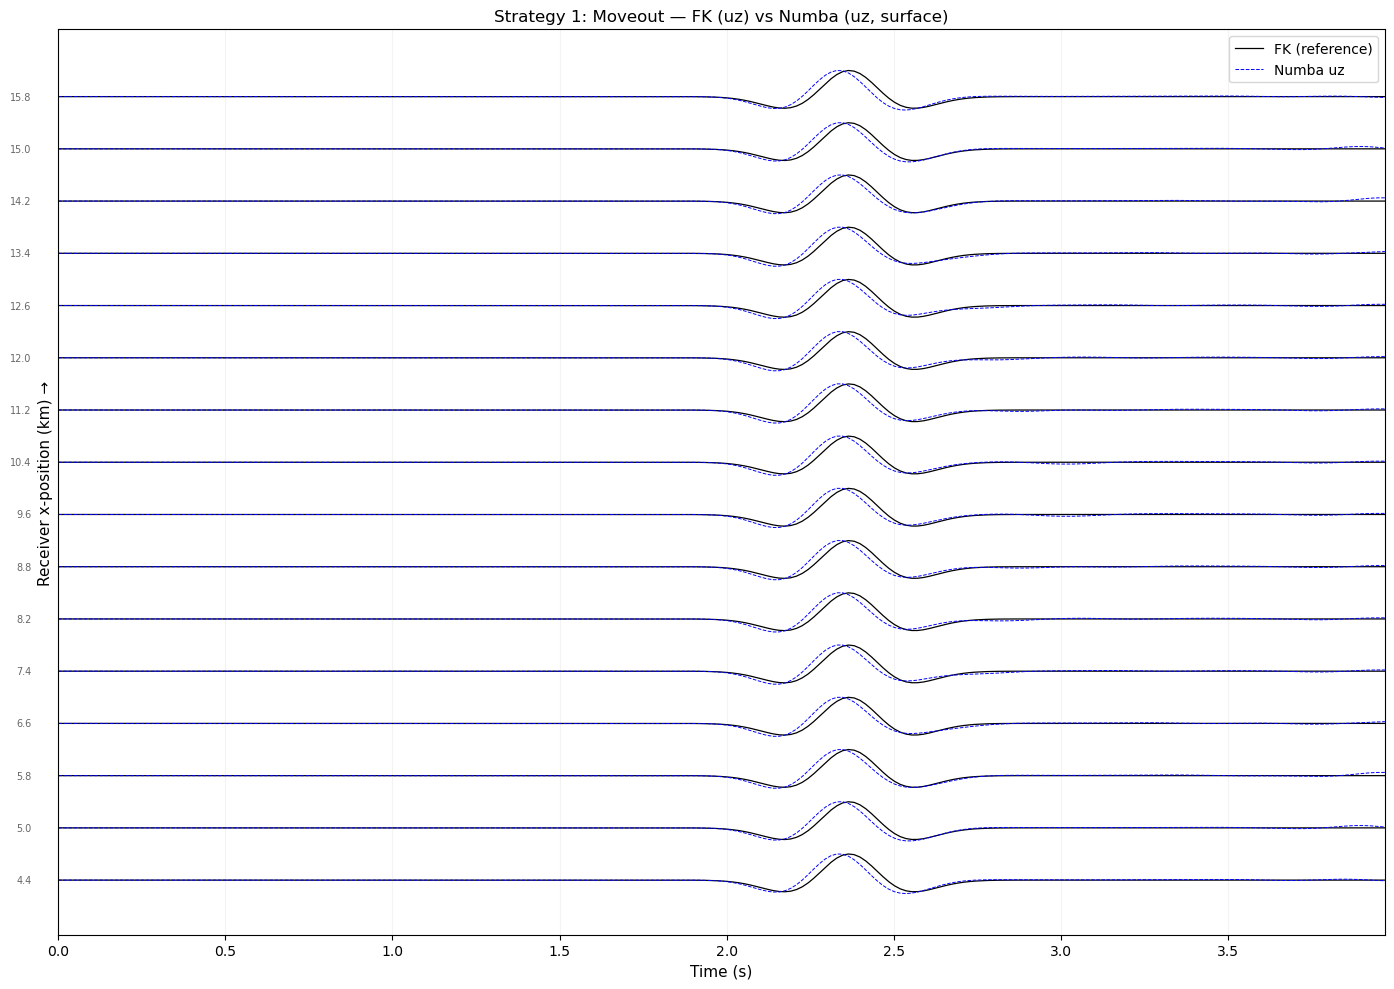

In [8]:
# --- Strategy 1: Moveout-style comparison ---

rcv_idx_moveout = np.linspace(
    config.npml + 2, config.nx - config.npml - 2, 16, dtype=int)

fig, ax = plt.subplots(figsize=(14, 10))

fk_all_uz = fk_result.uz
spacing = 2.0

for i, ircv in enumerate(rcv_idx_moveout):
    y_offset = i * spacing

    fk_tr = overlay_trace(fk_all_uz[ircv])
    ax.plot(t_arr, fk_tr + y_offset, 'k-', lw=0.9,
            label='FK (reference)' if i == 0 else None)

    numba_tr = overlay_trace(result_numba_s1['uz'][ircv])
    ax.plot(t_arr, numba_tr + y_offset, 'b--', lw=0.7,
            label='Numba uz' if i == 0 else None)

    x_km = rcv_x[ircv] / 1000
    ax.text(-0.08, y_offset, f'{x_km:.1f}', ha='right', va='center',
            fontsize=7, color='0.4')

ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Receiver x-position (km) \u2192', fontsize=11)
ax.set_title('Strategy 1: Moveout \u2014 FK (uz) vs Numba (uz, surface)',
             fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0, t_arr[-1])
ax.set_yticks([])
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()


---
## Strategy 2: Analytical Green's Function vs Numba FD

Validate the Numba FD solver against the **2D elastic displacement Green's function**
$G_{xx}$ for a point body force in a homogeneous full-space.

The Numba FD solver injects equal body forces $f_x = f_z$ at a single grid point.
For receivers at the same depth and lateral offset $r$ (angle $\theta = 0$), the
$f_z$ component produces no $u_x$ by symmetry ($G_{xz} = 0$ at $\theta = 0$).
The $u_x$ response is given by the 2D elastodynamic fundamental solution
(e.g. Aki & Richards 2002, *Quantitative Seismology*; Achenbach 1973):

$$G_{xx}(r, \omega) = \frac{i}{4\mu} \left[ \frac{H_1^{(2)}(k_s r)}{k_s r}
+ \frac{k_p^2}{k_s^2} H_0^{(2)}(k_p r)
- \frac{k_p}{k_s^2 r} H_1^{(2)}(k_p r) \right]$$

where $k_p = \omega / V_p$, $k_s = \omega / V_s$, $\mu = \rho V_s^2$. The dominant
term is the P-wave far-field $H_0^{(2)}(k_p r)$; the $H_1 / (kr)$ terms are near-field
corrections that decay as $r^{-3/2}$.

**Free-surface handling:** Receivers are placed at the same depth as the source
(lateral offsets only), so the direct P-wave arrives before any free-surface reflection.

In [9]:
from scipy.special import hankel2

def analytical_elastic_gxx(f0, vp, vs, rho_val, r, dt, nt, t0=None):
    """2D elastic displacement Green's function G_xx at theta=0.

    Computes u_x at a receiver located at lateral offset r (same depth
    as source, theta=0) due to a horizontal point body force f_x in a
    2D homogeneous elastic full-space.

    Uses the standard 2D frequency-domain elastodynamic fundamental
    solution (Aki & Richards, 2002; Achenbach, 1973):

        G_xx = (i/4mu)[H1(ks r)/(ks r)
               + (kp^2/ks^2) H0(kp r)
               - kp/(ks^2 r) H1(kp r)]
    """
    if t0 is None:
        t0 = 1.0 / f0
    T = nt * dt
    nf = nt // 2 + 1
    faxis = np.arange(nf) / T

    t_local = np.arange(nt) * dt
    src = (1 - 2*(np.pi*f0*(t_local - t0))**2) * np.exp(-(np.pi*f0*(t_local - t0))**2)
    S = np.fft.rfft(src)

    mu = rho_val * vs**2

    U = np.zeros(nf, dtype=complex)
    for i in range(1, nf):
        omega = 2 * np.pi * faxis[i]
        kp = omega / vp
        ks = omega / vs
        kpr = kp * r
        ksr = ks * r

        if kpr > 1e-10 and ksr > 1e-10:
            H0_p = hankel2(0, kpr)
            H1_p = hankel2(1, kpr)
            H1_s = hankel2(1, ksr)

            term_s_nf = H1_s / (ks * r)
            term_p_ff = (kp**2 / ks**2) * H0_p
            term_p_nf = -(kp / (ks**2 * r)) * H1_p

            G_xx = (1j / (4 * mu)) * (term_s_nf + term_p_ff + term_p_nf)
            U[i] = G_xx * S[i]

    return np.fft.irfft(U, n=nt)


# Receiver offsets: 8 distances for a dense moveout display
distances_dx = [5, 8, 12, 16, 20, 28, 36, 44]  # in units of dx
distances_m = [d * dx for d in distances_dx]

analytical_traces = {}
for r in distances_m:
    analytical_traces[r] = analytical_elastic_gxx(f0, vp, vs, rho_val, r, dt, nt)

print(f"Analytical traces computed at {len(distances_m)} offsets:")
print(f"  r = {[f'{r/1000:.1f} km' for r in distances_m]}")
for r, tr in analytical_traces.items():
    print(f"  r={r/1000:5.1f} km: max|u_x| = {np.max(np.abs(tr)):.3e}")


Analytical traces computed at 8 offsets:
  r = ['1.0 km', '1.6 km', '2.4 km', '3.2 km', '4.0 km', '5.6 km', '7.2 km', '8.8 km']
  r=  1.0 km: max|u_x| = 2.161e-12
  r=  1.6 km: max|u_x| = 1.365e-12
  r=  2.4 km: max|u_x| = 8.611e-13
  r=  3.2 km: max|u_x| = 7.089e-13
  r=  4.0 km: max|u_x| = 6.447e-13
  r=  5.6 km: max|u_x| = 5.552e-13
  r=  7.2 km: max|u_x| = 4.945e-13
  r=  8.8 km: max|u_x| = 4.514e-13


In [10]:
# --- Strategy 2: Numba FD with point body-force source ---

solver_s2 = FDDisplacementSolver(config, rho_ext, lam_ext, mu_ext)

# Source at center of domain (mid-depth to avoid free-surface reflections)
iz_src = config.nz // 2
ix_src_ext = config.npml + config.nx // 2
wavelet_s2 = make_ricker(f0, dt, nt)
source_s2 = PointBodyForceSource(ix_ext=ix_src_ext, iz=iz_src, wavelet=wavelet_s2)

# Receivers at same depth, lateral offsets
receivers_ix = np.array([ix_src_ext + int(d / dx) for d in distances_m], dtype=int)
receivers_iz = np.full(len(receivers_ix), iz_src, dtype=int)

# Verify receivers are within bounds
nx_tot = config.nx + 2 * config.npml
for i, ix in enumerate(receivers_ix):
    if ix >= nx_tot:
        print(f"WARNING: Receiver {i} at ix={ix} exceeds grid (nx_tot={nx_tot}). "
              f"Clamping to {nx_tot-1}.")
        receivers_ix[i] = nx_tot - 1

print(f"Source at (ix_ext={ix_src_ext}, iz={iz_src})")
print(f"Receivers at {len(receivers_ix)} offsets, ix_ext = {receivers_ix}")

t0_clock = time.perf_counter()
result_numba_s2 = run_standalone(solver_s2, source_s2, nt,
                                 receivers_ix=receivers_ix, receivers_iz=receivers_iz)
t_numba_s2 = time.perf_counter() - t0_clock
print(f"Numba FD completed in {t_numba_s2:.2f}s")
print(f"max|ux| = {np.max(np.abs(result_numba_s2['ux'])):.3e}")


Source at (ix_ext=70, iz=30)
Receivers at 8 offsets, ix_ext = [ 75  78  82  86  90  98 106 114]
Numba FD completed in 0.19s
max|ux| = 8.622e-08


In [11]:
# --- Strategy 2: Metrics (Numba FD vs Analytical) ---

print("Strategy 2: Numba FD vs Analytical Green's Function G_xx")
print("=" * 60)

t0_src = 1.0 / f0

s2_results = []
for i, r in enumerate(distances_m):
    it_start = max(0, int((r / vp + t0_src - 0.3) / dt))
    it_end = min(nt, int((r / vs + t0_src - 0.05) / dt))

    ana = analytical_traces[r][it_start:it_end]
    fd_trace = result_numba_s2['ux'][i, it_start:it_end]

    scale_numba = find_best_scale(ana, fd_trace)
    fd_scaled = fd_trace * scale_numba
    cc_numba = waveform_cc(ana, fd_scaled)

    s2_results.append({
        'r': r,
        'cc_numba': cc_numba,
        'scale_numba': scale_numba,
        'it_start': it_start,
        'it_end': it_end,
    })

    print(f"  r={r/1000:5.1f} km: Numba CC={cc_numba:.4f}"
          f"  window=[{it_start*dt:.2f}, {it_end*dt:.2f}s]")

all_pass_numba = all(r['cc_numba'] > 0.95 for r in s2_results)
print(f"\nNumba FD: {'PASS' if all_pass_numba else 'FAIL'} (threshold CC > 0.95)")


Strategy 2: Numba FD vs Analytical Green's Function G_xx
  r=  1.0 km: Numba CC=0.9820  window=[0.36, 0.72s]
  r=  1.6 km: Numba CC=0.9847  window=[0.47, 0.90s]
  r=  2.4 km: Numba CC=0.9805  window=[0.59, 1.14s]
  r=  3.2 km: Numba CC=0.9741  window=[0.72, 1.36s]
  r=  4.0 km: Numba CC=0.9705  window=[0.86, 1.59s]
  r=  5.6 km: Numba CC=0.9686  window=[1.12, 2.05s]
  r=  7.2 km: Numba CC=0.9662  window=[1.40, 2.52s]
  r=  8.8 km: Numba CC=0.9628  window=[1.66, 2.99s]

Numba FD: PASS (threshold CC > 0.95)


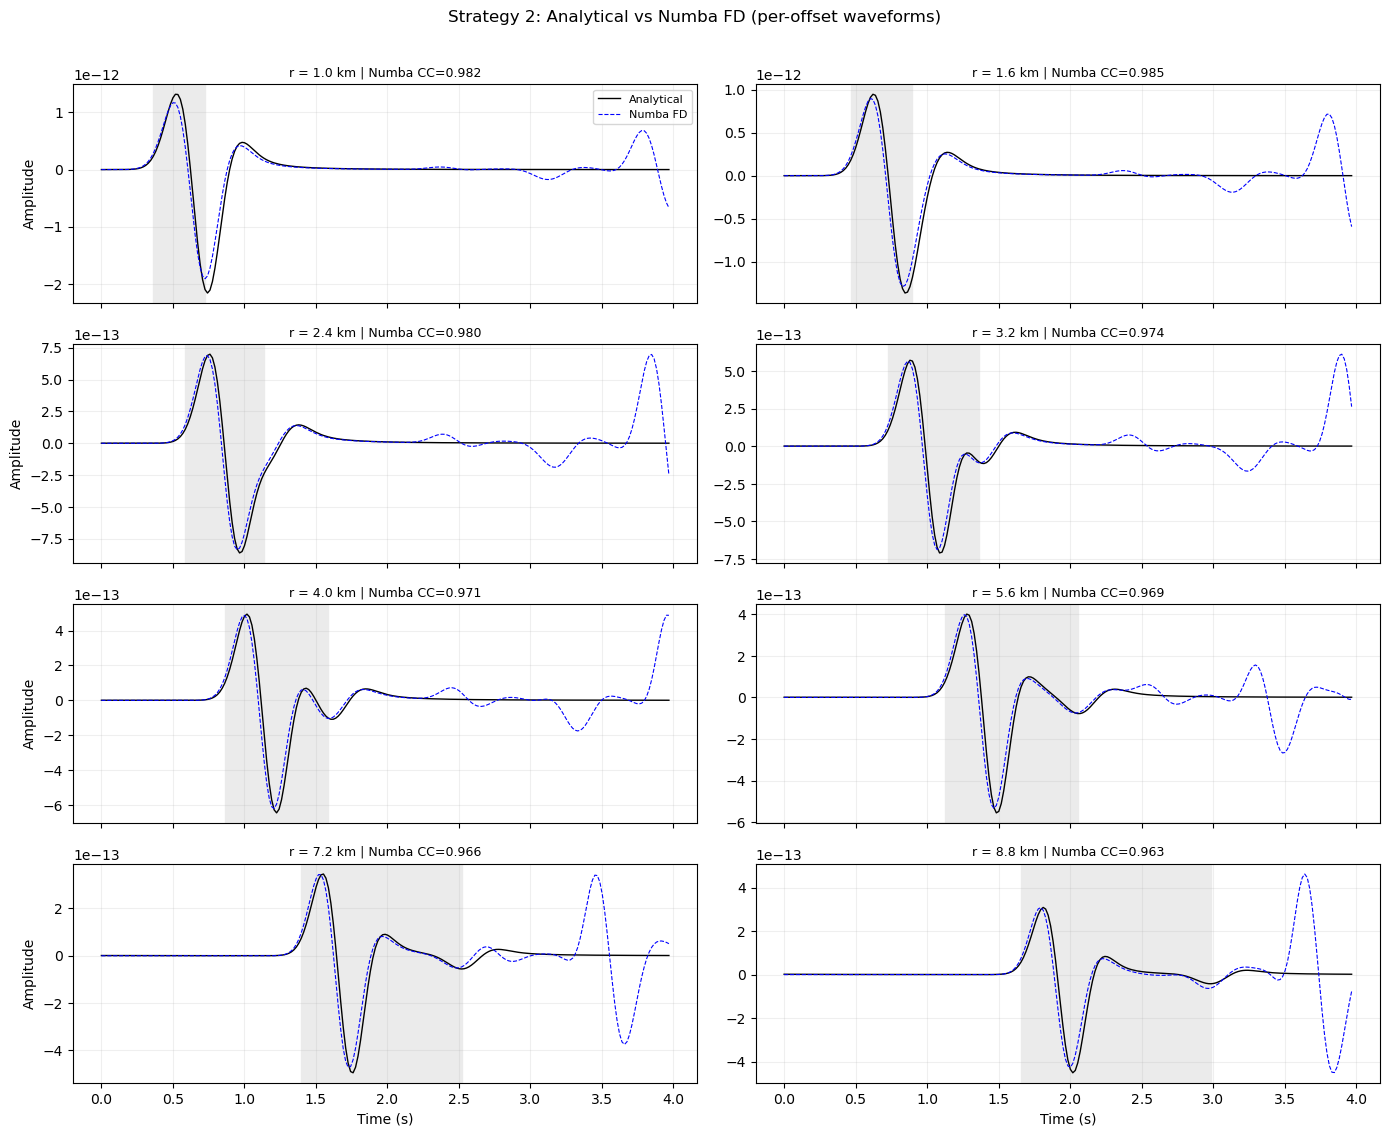

In [12]:
# --- Strategy 2: Per-offset waveform comparison (Analytical vs Numba) ---

n_offsets = len(distances_m)
n_cols = 2
n_rows = (n_offsets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.8 * n_rows), sharex=True)
axes_flat = axes.flatten()

for i, (r, res) in enumerate(zip(distances_m, s2_results)):
    ax = axes_flat[i]
    ana_full = analytical_traces[r]
    fd_full = result_numba_s2['ux'][i] * res['scale_numba']

    ax.plot(t_arr, ana_full, 'k-', lw=1.0, label='Analytical')
    ax.plot(t_arr, fd_full, 'b--', lw=0.8, label='Numba FD')

    t_lo = res['it_start'] * dt
    t_hi = res['it_end'] * dt
    ax.axvspan(t_lo, t_hi, color='0.92', zorder=0)

    ax.set_title(f"r = {r/1000:.1f} km | Numba CC={res['cc_numba']:.3f}", fontsize=9)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.2)

for j in range(n_offsets, len(axes_flat)):
    axes_flat[j].set_visible(False)

for ax in axes_flat[::n_cols]:
    ax.set_ylabel('Amplitude')
for ax in axes_flat[-n_cols:]:
    ax.set_xlabel('Time (s)')

plt.suptitle("Strategy 2: Analytical vs Numba FD (per-offset waveforms)",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


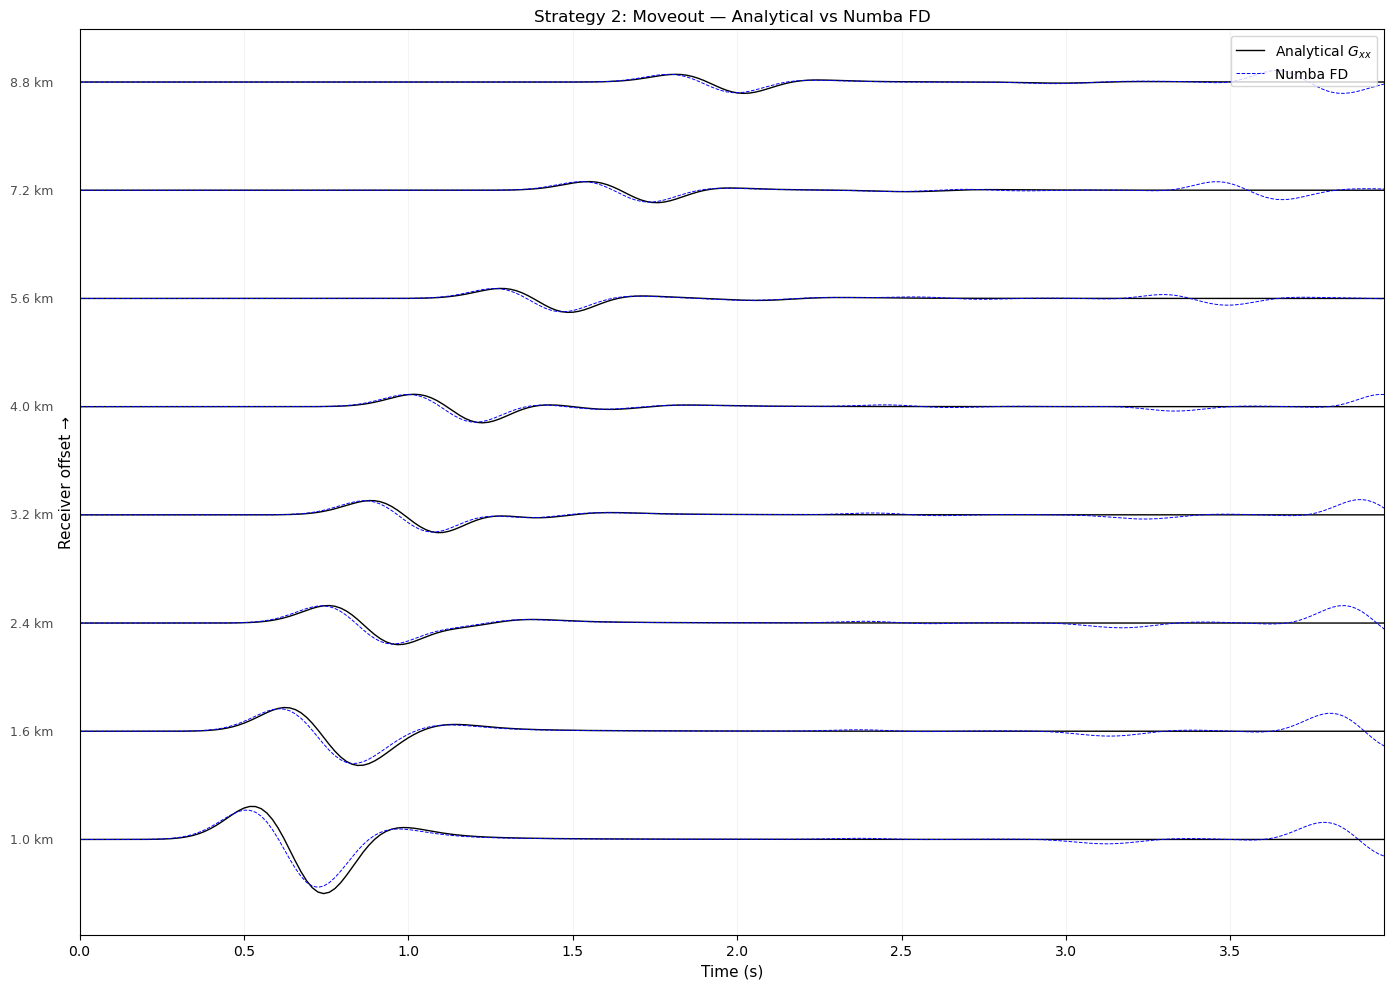

In [13]:
# --- Strategy 2: Moveout-style comparison ---

fig, ax = plt.subplots(figsize=(14, 10))

spacing = 2.0
norm_s2 = max(np.max(np.abs(analytical_traces[r])) for r in distances_m) + 1e-30

for i, (r, res) in enumerate(zip(distances_m, s2_results)):
    y_offset = i * spacing

    ana_tr = analytical_traces[r] / norm_s2
    ax.plot(t_arr, ana_tr + y_offset, 'k-', lw=1.0,
            label='Analytical $G_{xx}$' if i == 0 else None)

    fd_tr = result_numba_s2['ux'][i] * res['scale_numba'] / norm_s2
    ax.plot(t_arr, fd_tr + y_offset, 'b--', lw=0.7,
            label='Numba FD' if i == 0 else None)

    ax.text(-0.08, y_offset, f'{r/1000:.1f} km', ha='right', va='center',
            fontsize=9, color='0.3')

ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Receiver offset \u2192', fontsize=11)
ax.set_title("Strategy 2: Moveout \u2014 Analytical vs Numba FD",
             fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0, t_arr[-1])
ax.set_yticks([])
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()


---
## Summary

| Strategy | Comparison | CC Threshold | Notes |
|----------|-----------|--------------|-------|
| 1 | FK vs Numba FD (aligned) | > 0.90 | Explosive line source vs FK plane wave |
| 2 | Numba FD vs Analytical $G_{xx}$ | > 0.95 | **Primary validation** — point body-force Green's function |

**Interpretation:**
- Strategy 2 validates Numba FD against an independent analytical solution (strongest test).
- Strategy 1 confirms the Numba FD solver matches the semi-analytical FK solution.
